---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---


# Multivariate Normal Distribution

## 1\. Definition and Characterization

The **Multivariate Normal (MVN) distribution** is the fundamental vector generalization of the univariate [Normal Distribution](normal-distribution.ipynb). It forms the theoretical backbone of multivariate statistics, linear regression, Gaussian processes, and principal component analysis.

While one might attempt to define the multivariate Normal distribution using a joint density function, that approach fails when the covariance matrix is singular (degenerate). Instead, the rigorous, universally applicable definition characterizes the distribution via all possible **linear combinations** of its components.

::: {#def-mvn}
## Multivariate Normal Distribution
A random vector $\vec{X} = (X_1, X_2, \dots, X_k)^T$ is said to have a **Multivariate Normal distribution** if every linear combination of its components is a univariate Normal random variable. 

Equivalently, for any constant vector $\vec{t} = (t_1, t_2, \dots, t_k)^T \in \mathbb{R}^k$, the scalar dot-product:

$$
Y = \vec{t}^T \vec{X} = t_1 X_1 + t_2 X_2 + \dots + t_k X_k
$$

follows a univariate Normal distribution (where a constant random variable with variance $0$ is treated as a degenerate Normal distribution).

We denote this vector distribution as:

$$
\vec{X} \sim \mathcal{N}_k(\vec{\mu}, \boldsymbol{\Sigma})
$$

where:
* $\vec{\mu} = E[\vec{X}] = (\mu_1, \dots, \mu_k)^T \in \mathbb{R}^k$ is the [mean vector](expectation.ipynb).
* $\boldsymbol{\Sigma} = \text{Cov}(\vec{X}) \in \mathbb{R}^{k \times k}$ is the symmetric, positive semi-definite [covariance matrix](covariance-and-correlation.ipynb) whose $(i, j)$th entry is $\Sigma_{ij} = \text{Cov}(X_i, X_j)$.
:::


## 2\. Moment Generating Function (MGF)

The linear combination definition allows us to derive the joint [Moment Generating Function](moment-generating-functions.ipynb) of a Multivariate Normal vector cleanly and elegantly.

::: {#thm-mvn-mgf}
## MGF of the Multivariate Normal Distribution
Let $\vec{X} \sim \mathcal{N}_k(\vec{\mu}, \boldsymbol{\Sigma})$. Its joint moment generating function $M_{\vec{X}}(\vec{t}): \mathbb{R}^k \to \mathbb{R}$ is given by:

$$
M_{\vec{X}}(\vec{t}) = E\left[e^{\vec{t}^T \vec{X}}\right] = \exp\left( \vec{t}^T \vec{\mu} + \frac{1}{2} \vec{t}^T \boldsymbol{\Sigma} \vec{t} \right), \quad \text{for all } \vec{t} \in \mathbb{R}^k
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Multivariate Normal MGF
Let $\vec{t} = (t_1, t_2, \dots, t_k)^T \in \mathbb{R}^k$ be an arbitrary constant vector.

By Definition, because $\vec{X}$ is Multivariate Normal, the scalar projection $Y = \vec{t}^T \vec{X} = \sum_{i=1}^k t_i X_i$ is a univariate Normal random variable.

We determine the mean and variance of this univariate Normal variable $Y$:

$$
\begin{aligned}
E[Y] &= E\left[ \sum_{i=1}^k t_i X_i \right] = \sum_{i=1}^k t_i E[X_i] = \sum_{i=1}^k t_i \mu_i = \vec{t}^T \vec{\mu} \\
\text{Var}(Y) &= \text{Var}(\vec{t}^T \vec{X}) = \vec{t}^T \text{Cov}(\vec{X}) \vec{t} = \vec{t}^T \boldsymbol{\Sigma} \vec{t}
\end{aligned}
$$

Thus, $Y \sim \mathcal{N}\left( \vec{t}^T \vec{\mu}, \, \vec{t}^T \boldsymbol{\Sigma} \vec{t} \right)$.

Now, evaluate the joint MGF of $\vec{X}$ at the vector $\vec{t}$:

$$
\begin{aligned}
M_{\vec{X}}(\vec{t}) &= E\left[e^{\vec{t}^T \vec{X}}\right] \\
&= E\left[e^{1 \cdot Y}\right] \\
&= M_Y(1)
\end{aligned}
$$

Recall that the MGF of a univariate Normal random variable $Y \sim \mathcal{N}(m, s^2)$ evaluated at argument $u$ is $M_Y(u) = \exp\left( m u + \frac{1}{2} s^2 u^2 \right)$. Evaluating this at $u = 1$ yields:

$$
M_Y(1) = \exp\left( E[Y] + \frac{1}{2} \text{Var}(Y) \right)
$$

Substituting $E[Y] = \vec{t}^T \vec{\mu}$ and $\text{Var}(Y) = \vec{t}^T \boldsymbol{\Sigma} \vec{t}$ directly into this expression:

$$
\begin{aligned}
M_{\vec{X}}(\vec{t}) &= \exp\left( (t_1 \mu_1 + \dots + t_k \mu_k) + \frac{1}{2} \text{Var}(t_1 X_1 + \dots + t_k X_k) \right) \\
&= \exp\left( \vec{t}^T \vec{\mu} + \frac{1}{2} \vec{t}^T \boldsymbol{\Sigma} \vec{t} \right)
\end{aligned}
$$

$\blacksquare$
:::


## 3\. Uncorrelated Implies Independent Within MVN

One of the most powerful and celebrated consequences of jointly Normal variables is that zero covariance (being uncorrelated) guarantees full statistical [independence](independence-of-rvs.ipynb).

::: {#thm-mvn-uncorrelated-independent}
## Uncorrelated Implies Independent for MVN
Let $\vec{X} \sim \mathcal{N}_k(\vec{\mu}, \boldsymbol{\Sigma})$ be partitioned into two subvectors:

$$
\vec{X} = \begin{pmatrix} \vec{X}_1 \\ \vec{X}_2 \end{pmatrix}
$$

where $\vec{X}_1 \in \mathbb{R}^p$ and $\vec{X}_2 \in \mathbb{R}^{k-p}$. Partition the covariance matrix correspondingly:

$$
\boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{11} & \boldsymbol{\Sigma}_{12} \\ \boldsymbol{\Sigma}_{21} & \boldsymbol{\Sigma}_{22} \end{pmatrix}
$$

If $\vec{X}_1$ and $\vec{X}_2$ are **uncorrelated**—meaning their cross-covariance block $\boldsymbol{\Sigma}_{12} = \text{Cov}(\vec{X}_1, \vec{X}_2) = \mathbf{0}$—then $\vec{X}_1$ and $\vec{X}_2$ are **statistically independent**.
:::

::: {.callout-tip collapse="true"}
## Proof via MGF Factorization
Partition the mean vector $\vec{\mu} = \begin{pmatrix} \vec{\mu}_1 \\ \vec{\mu}_2 \end{pmatrix}$ and the argument vector $\vec{t} = \begin{pmatrix} \vec{t}_1 \\ \vec{t}_2 \end{pmatrix}$, where $\vec{t}_1 \in \mathbb{R}^p$ and $\vec{t}_2 \in \mathbb{R}^{k-p}$.

Because $\vec{X}_1$ and $\vec{X}_2$ are uncorrelated, $\boldsymbol{\Sigma}_{12} = \mathbf{0}$ and $\boldsymbol{\Sigma}_{21} = \boldsymbol{\Sigma}_{12}^T = \mathbf{0}$. The covariance matrix becomes block-diagonal:

$$
\boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{11} & \mathbf{0} \\ \mathbf{0} & \boldsymbol{\Sigma}_{22} \end{pmatrix}
$$

Evaluate the quadratic form $\vec{t}^T \boldsymbol{\Sigma} \vec{t}$ under this block-diagonal structure:

$$
\begin{aligned}
\vec{t}^T \boldsymbol{\Sigma} \vec{t} &= \begin{pmatrix} \vec{t}_1^T & \vec{t}_2^T \end{pmatrix} \begin{pmatrix} \boldsymbol{\Sigma}_{11} & \mathbf{0} \\ \mathbf{0} & \boldsymbol{\Sigma}_{22} \end{pmatrix} \begin{pmatrix} \vec{t}_1 \\ \vec{t}_2 \end{pmatrix} \\
&= \begin{pmatrix} \vec{t}_1^T \boldsymbol{\Sigma}_{11} & \vec{t}_2^T \boldsymbol{\Sigma}_{22} \end{pmatrix} \begin{pmatrix} \vec{t}_1 \\ \vec{t}_2 \end{pmatrix} \\
&= \vec{t}_1^T \boldsymbol{\Sigma}_{11} \vec{t}_1 + \vec{t}_2^T \boldsymbol{\Sigma}_{22} \vec{t}_2
\end{aligned}
$$

Similarly, the linear term decomposes as:

$$
\vec{t}^T \vec{\mu} = \vec{t}_1^T \vec{\mu}_1 + \vec{t}_2^T \vec{\mu}_2
$$

Substitute these decompositions back into the joint MGF formula:

$$
\begin{aligned}
M_{\vec{X}}(\vec{t}) &= \exp\left( \vec{t}^T \vec{\mu} + \frac{1}{2} \vec{t}^T \boldsymbol{\Sigma} \vec{t} \right) \\
&= \exp\left( \vec{t}_1^T \vec{\mu}_1 + \vec{t}_2^T \vec{\mu}_2 + \frac{1}{2} \left(\vec{t}_1^T \boldsymbol{\Sigma}_{11} \vec{t}_1 + \vec{t}_2^T \boldsymbol{\Sigma}_{22} \vec{t}_2\right) \right) \\
&= \exp\left( \vec{t}_1^T \vec{\mu}_1 + \frac{1}{2} \vec{t}_1^T \boldsymbol{\Sigma}_{11} \vec{t}_1 \right) \cdot \exp\left( \vec{t}_2^T \vec{\mu}_2 + \frac{1}{2} \vec{t}_2^T \boldsymbol{\Sigma}_{22} \vec{t}_2 \right) \\
&= M_{\vec{X}_1}(\vec{t}_1) \cdot M_{\vec{X}_2}(\vec{t}_2)
\end{aligned}
$$

Because the joint MGF factors perfectly into the product of the marginal MGFs for all $\vec{t}_1, \vec{t}_2$, the random vectors $\vec{X}_1$ and $\vec{X}_2$ are statistically independent. $\blacksquare$
:::

::: {.callout-warning}
## Critical Distinction: General Variables vs. MVN
For general (non-normal) random variables, **uncorrelated does NOT imply independent**. Zero covariance only indicates the absence of *linear* dependence, leaving room for strong non-linear relationships (e.g., $X \sim \mathcal{N}(0, 1)$ and $Y = X^2$ have $\text{Cov}(X, Y) = 0$, but are deterministically dependent). Furthermore, even if two variables $X_1$ and $X_2$ are marginally Normal and uncorrelated, they are not necessarily independent unless their **joint** distribution is Multivariate Normal!
:::


## 4\. Joint Probability Density Function (Non-Singular Case)

When the covariance matrix $\boldsymbol{\Sigma}$ is positive definite ($\det(\boldsymbol{\Sigma}) > 0$), the distribution is non-singular, and the joint probability density function exists in explicit closed form across $\mathbb{R}^k$.

::: {#thm-mvn-pdf}
## Joint PDF of Multivariate Normal
If $\vec{X} \sim \mathcal{N}_k(\vec{\mu}, \boldsymbol{\Sigma})$ with positive definite $\boldsymbol{\Sigma}$, its joint probability density function is given by:

$$
f_{\vec{X}}(\vec{x}) = \frac{1}{(2\pi)^{k/2} \det(\boldsymbol{\Sigma})^{1/2}} \exp\left( -\frac{1}{2} (\vec{x} - \vec{\mu})^T \boldsymbol{\Sigma}^{-1} (\vec{x} - \vec{\mu}) \right), \quad \vec{x} \in \mathbb{R}^k
$$
:::

::: {.callout-note}
## Intuition: Mahalanobis Distance and Elliptical Contours
The exponent contains the quadratic form $\Delta^2 = (\vec{x} - \vec{\mu})^T \boldsymbol{\Sigma}^{-1} (\vec{x} - \vec{\mu})$, known as the **Mahalanobis distance squared** from $\vec{x}$ to the mean vector $\vec{\mu}$. 

Because $\Delta^2$ accounts for both the scaling and correlations of the components, contours of constant density (where $f_{\vec{X}}(\vec{x}) = c$) correspond to sets of constant Mahalanobis distance. Geometrically, these contours form concentric **ellipsoids** centered at $\vec{\mu}$. Furthermore, the random quantity $\Delta^2 = (\vec{X} - \vec{\mu})^T \boldsymbol{\Sigma}^{-1} (\vec{X} - \vec{\mu})$ follows exactly a [Chi-Square Distribution](chi-square-distribution.ipynb) with $k$ degrees of freedom!
:::


## 5\. Visualizing Bivariate Normal Contours and Scatter

In the $k=2$ (bivariate) case, the covariance matrix can be parameterized using the individual standard deviations $\sigma_1, \sigma_2$ and the correlation coefficient $\rho \in (-1, 1)$:

$$
\boldsymbol{\Sigma} = \begin{pmatrix} \sigma_1^2 & \rho \sigma_1 \sigma_2 \\ \rho \sigma_1 \sigma_2 & \sigma_2^2 \end{pmatrix}
$$

The code below visualizes how $\rho$ dictates the orientation and eccentricity of the elliptical density contours.

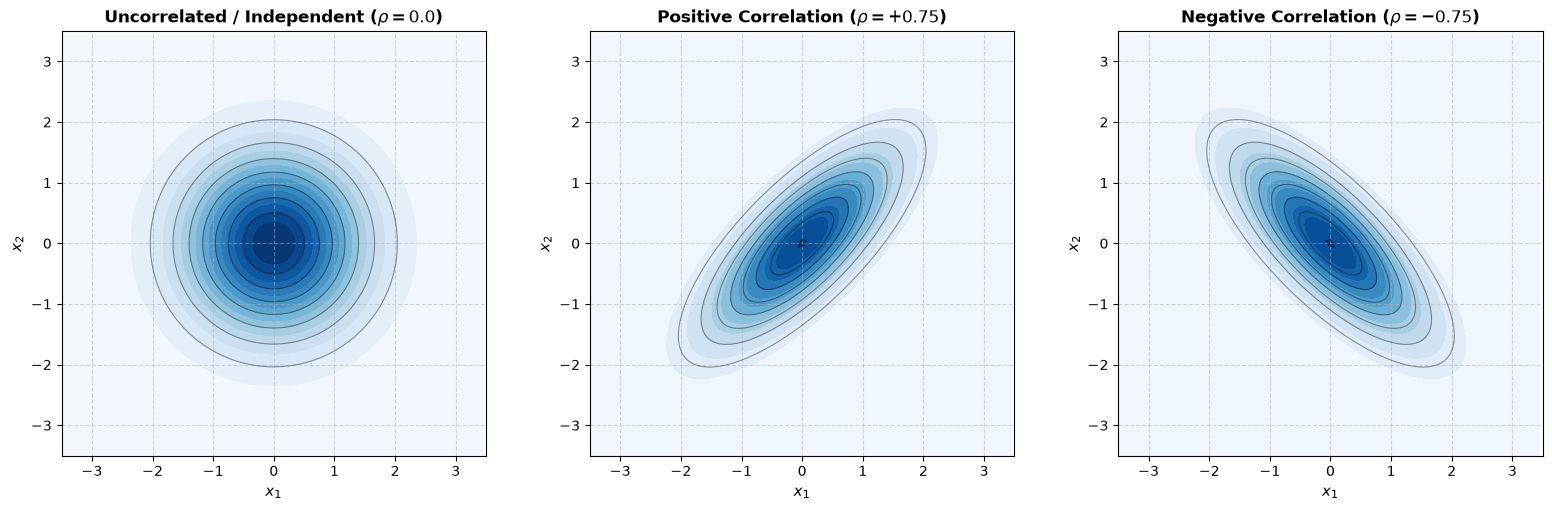

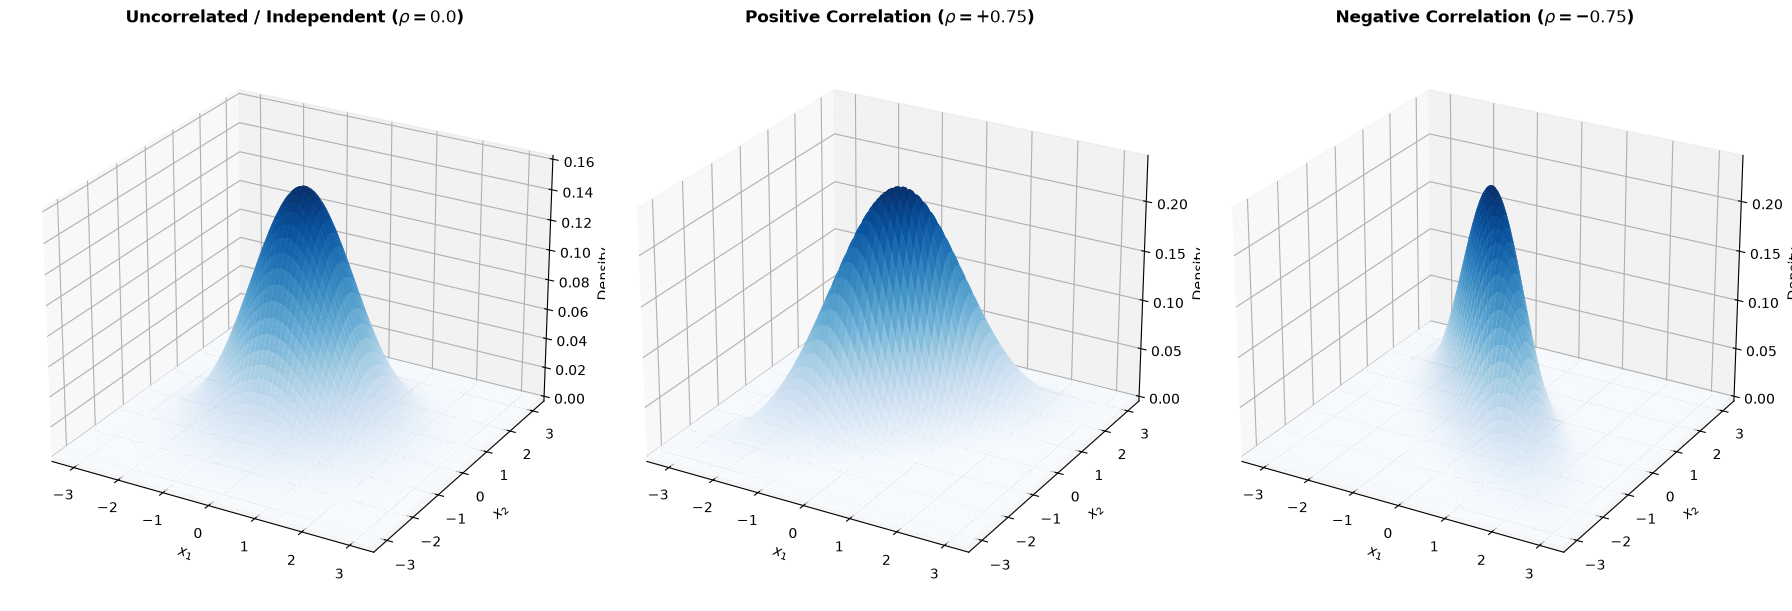

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Grid setup
x, y = np.mgrid[-3.5:3.5:.05, -3.5:3.5:.05]
pos = np.dstack((x, y))

# Define three correlation cases
rhos = [0.0, 0.75, -0.75]
titles = [r'Uncorrelated / Independent ($\rho = 0.0$)',
          r'Positive Correlation ($\rho = +0.75$)',
          r'Negative Correlation ($\rho = -0.75$)']

# ---------------------------------------------------------
# Figure 1: 2D filled contour plots
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))

for ax, rho, title in zip(axes1, rhos, titles):
    cov = [[1.0, rho], [rho, 1.0]]
    rv = multivariate_normal([0.0, 0.0], cov)
    z = rv.pdf(pos)

    contour = ax.contourf(x, y, z, levels=15, cmap='Blues')
    ax.contour(x, y, z, levels=8, colors='black', alpha=0.4, linewidths=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

fig1.tight_layout()
# ---------------------------------------------------------
# Figure 2: 3D surface plots
# ---------------------------------------------------------
fig2 = plt.figure(figsize=(18, 6))

for i, (rho, title) in enumerate(zip(rhos, titles), start=1):
    cov = [[1.0, rho], [rho, 1.0]]
    rv = multivariate_normal([0.0, 0.0], cov)
    z = rv.pdf(pos)

    ax = fig2.add_subplot(1, 3, i, projection='3d')
    surf = ax.plot_surface(x, y, z, cmap='Blues', edgecolor='none',
                            antialiased=True, rstride=2, cstride=2)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('$x_1$', fontsize=10)
    ax.set_ylabel('$x_2$', fontsize=10)
    ax.set_zlabel('Density', fontsize=10)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.view_init(elev=25, azim=-60)

fig2.tight_layout()

plt.show()